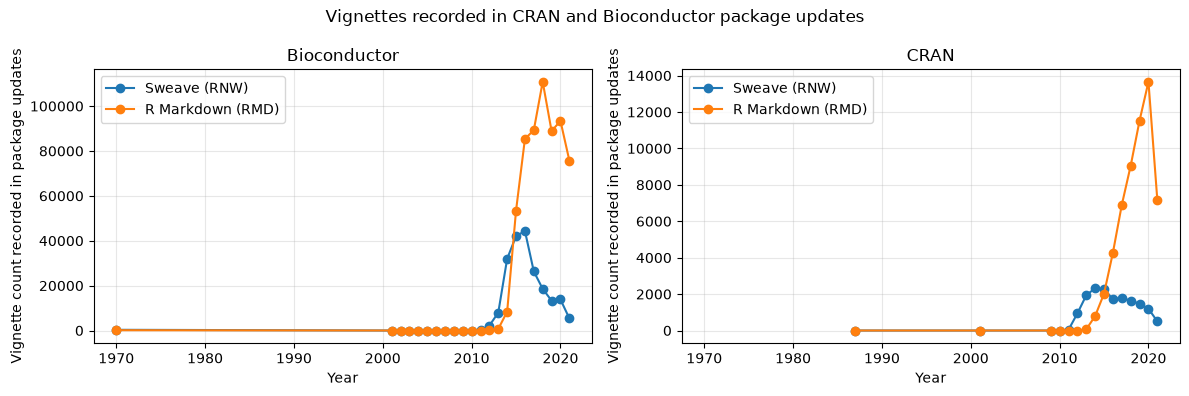

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

base_url = (
    "https://raw.githubusercontent.com/rfordatascience/tidytuesday/"
    "main/data/2022/2022-03-15"
)

datasets = {
    "Bioconductor": pd.read_csv(f"{base_url}/bioc.csv"),
    "CRAN": pd.read_csv(f"{base_url}/cran.csv"),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

for ax, (source, data) in zip(axes, datasets.items()):
    data["date"] = pd.to_datetime(data["date"], errors="coerce")

    annual = (
        data.assign(year=data["date"].dt.year)
        .groupby("year")[["rnw", "rmd"]]
        .sum(min_count=1)
    )

    ax.plot(annual.index, annual["rnw"], marker="o", label="Sweave (RNW)")
    ax.plot(annual.index, annual["rmd"], marker="o", label="R Markdown (RMD)")
    ax.set_title(source)
    ax.set_xlabel("Year")
    ax.set_ylabel("Vignette count recorded in package updates")
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("Vignettes recorded in CRAN and Bioconductor package updates")
fig.tight_layout()
plt.show()